# Assessment Task 4.1 Supplementary Activity on Transfer Learning

* Perform Transfer Learning on PyTorch, afterwards perform transfer learning (either fine tuning or a feature extraction) on your chosen dataset.
* Take note of your experiment.
* Reach at least 95% test accuracy.


## Libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import Data

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa4.1/SalmonScan A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture/SalmonScan/Augmented'

Using cuda device
Mounted at /content/drive


## Explore dataset

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # ResNet50 expects 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load twice — train gets augmentation, val/test does not
train_full = datasets.ImageFolder(root=dataset_path, transform=train_transform)
test_full  = datasets.ImageFolder(root=dataset_path, transform=val_transform)

class_names = train_full.classes
num_classes = len(class_names)
print(f"Classes    : {class_names}")
print(f"Total imgs : {len(train_full)}")

Classes    : ['FreshFish', 'InfectedFish']
Total imgs : 1208


## split data, create dataloaders

In [4]:
from torch.utils.data import Subset

n       = len(train_full)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

# Fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(n, generator=generator).tolist()

train_indices = indices[:n_train]
val_indices   = indices[n_train:n_train + n_val]
test_indices  = indices[n_train + n_val:]

train_ds = Subset(train_full, train_indices)
val_ds   = Subset(test_full,  val_indices)
test_ds  = Subset(test_full,  test_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 966 | Val: 120 | Test: 122


## Train/Test/Evaluate Functions

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), batch * 32 + len(X)
            print(f"  loss: {loss:>7f}  [{current:>4d}/{size:>4d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size        = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct   /= size
    print(f"  Accuracy: {(100*correct):>0.1f}%  |  Avg loss: {test_loss:>8f}")
    return round(100 * correct, 2), round(test_loss, 6)

def evaluate(model, test_loader, label="Model"):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            all_preds.extend(model(X).argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    print(f"\n{'='*50}")
    print(f" Evaluation: {label}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

# ResNet50 (pretrained model) finetuning

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]



── Finetuned ResNet50 Training ──

Epoch 1
-------------------------------
  loss: 0.725173  [  32/ 966]
  loss: 0.379134  [ 352/ 966]
  loss: 0.277436  [ 672/ 966]
  loss: 0.422617  [ 966/ 966]
Train:
  Accuracy: 95.9%  |  Avg loss: 0.290908
Val:
  Accuracy: 96.7%  |  Avg loss: 0.286531

Epoch 2
-------------------------------
  loss: 0.274972  [  32/ 966]
  loss: 0.276510  [ 352/ 966]
  loss: 0.248756  [ 672/ 966]
  loss: 0.240449  [ 966/ 966]
Train:
  Accuracy: 98.2%  |  Avg loss: 0.236551
Val:
  Accuracy: 98.3%  |  Avg loss: 0.234256

Epoch 3
-------------------------------
  loss: 0.248704  [  32/ 966]
  loss: 0.224521  [ 352/ 966]
  loss: 0.218250  [ 672/ 966]
  loss: 0.243460  [ 966/ 966]
Train:
  Accuracy: 99.8%  |  Avg loss: 0.214663
Val:
  Accuracy: 99.2%  |  Avg loss: 0.221408

Epoch 4
-------------------------------
  loss: 0.216441  [  32/ 966]
  loss: 0.304599  [ 352/ 966]
  loss: 0.254859  [ 672/ 966]
  loss: 0.209033  [ 966/ 966]
Train:
  Accuracy: 99.4%  |  Avg loss: 

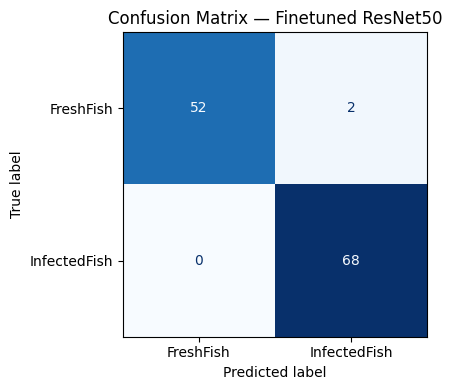

In [6]:
#Finetuned ResNet50 (with overfitting prevention)
model_ft = models.resnet50(weights='IMAGENET1K_V1')

# Partial unfreezing — only unfreeze the last 2 layer groups
# Freezing early layers preserves general features (edges, textures)
# Only fine-tune deeper layers that learn task-specific features
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze only layer3, layer4, and fc
for param in model_ft.layer3.parameters():
    param.requires_grad = True
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Replace final layer with stronger regularization
model_ft.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model_ft.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
model_ft = model_ft.to(device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)# label smoothing reduces overconfidence

# Different LRs per layer group — lower for pretrained, higher for new layers
optimizer = torch.optim.Adam([
    {'params': model_ft.layer3.parameters(), 'lr': 1e-5},# very low — mostly frozen knowledge
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},# low — fine-tune carefully
    {'params': model_ft.fc.parameters(),     'lr': 1e-3},# normal — new layer trains freely
], weight_decay=1e-4)# L2 regularization

# ReduceLROnPlateau reduces LR when val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5,
)

#Early stopping helper
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_weights = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: no improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                print("  Stopping early — restoring best weights")
                model.load_state_dict(self.best_weights)
                return True
        return False

early_stopping = EarlyStopping(patience=4)

epochs = 10
ft_train_acc,  ft_val_acc  = [], []
ft_train_loss, ft_val_loss = [], []

print("\n── Finetuned ResNet50 Training ──")
for t in range(epochs):
    print(f"\nEpoch {t+1}\n-------------------------------")
    train_loop(train_loader, model_ft, loss_fn, optimizer)
    print("Train:"); t_acc, t_loss = test_loop(train_loader, model_ft, loss_fn)
    print("Val:");   v_acc, v_loss = test_loop(val_loader,   model_ft, loss_fn)

    scheduler.step(v_loss)                             # ReduceLROnPlateau needs val loss

    ft_train_acc.append(t_acc);  ft_val_acc.append(v_acc)
    ft_train_loss.append(t_loss); ft_val_loss.append(v_loss)

    if early_stopping.step(v_loss, model_ft):# stop if val loss stops improving
        epochs = t + 1# update for accurate chart x-axis
        break

print("\nDone!")

# Evaluate on test set
ft_preds, ft_labels = evaluate(model_ft, test_loader, label="Finetuned ResNet50")

## Evaluation

Final Test Accuracy Summary
  Finetuned ResNet50 : 98.36%


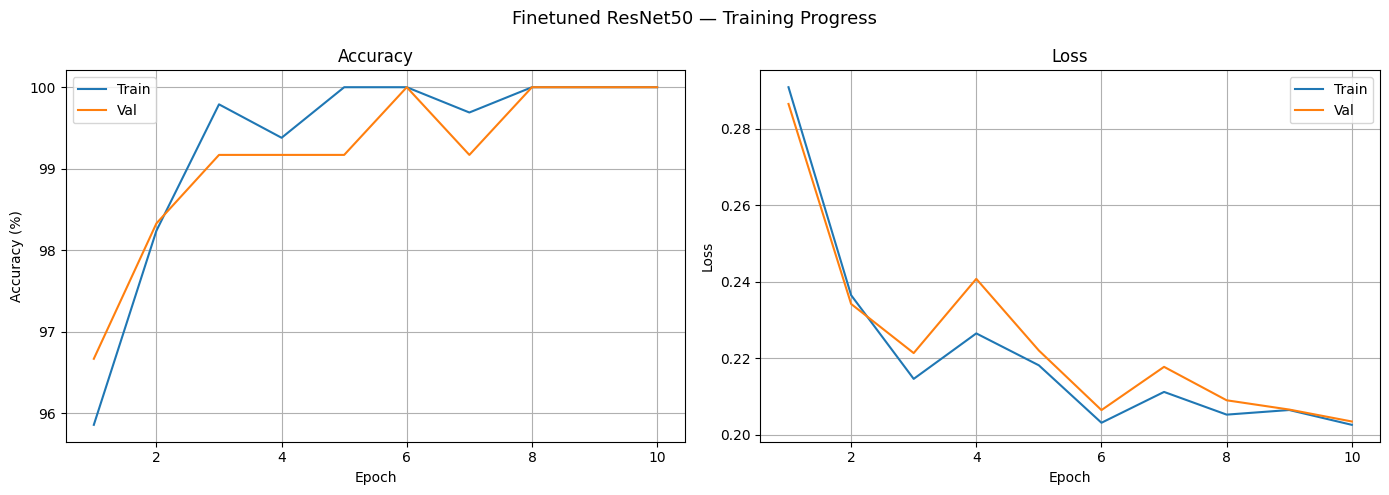

Model saved to Google Drive!


In [8]:
from sklearn.metrics import accuracy_score

#1. Final test accuracy summary
ft_acc = accuracy_score(ft_labels, ft_preds) * 100

print("Final Test Accuracy Summary")
print(f"  Finetuned ResNet50 : {ft_acc:.2f}%")

#2. Validation curves
ft_epochs = range(1, len(ft_val_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Finetuned ResNet50 — Training Progress", fontsize=13)

axes[0].plot(ft_epochs, ft_train_acc, label="Train")
axes[0].plot(ft_epochs, ft_val_acc,   label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ft_epochs, ft_train_loss, label="Train")
axes[1].plot(ft_epochs, ft_val_loss,   label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#3. Save model to Drive
base_path = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa4.2/'
torch.save(model_ft.state_dict(), base_path + 'resnet50_finetuned.pth')
print("Model saved to Google Drive!")